# Anti-Money Laundering System using Integrated Machine Learning Techniques:

This notebook is dedicated to developing an advanced Anti-Money Laundering (AML) detection system using machine learning techniques. The primary aim is to identify fraudulent financial transactions by using both supervised and unsupervised learning methods. Specifically, we will integrate K-means Clustering with Random Forest classification to enhance detection accuracy and reduce false positives.

The dataset, sourced from Kaggle, comprises various attributes including 'Amount', 'Time', and several scaled features. This project will encompass several stages, including data preprocessing, exploratory data analysis, model training, and evaluation. Through this comprehensive approach, we aim to create a robust machine learning model capable of effectively detecting suspicious transaction patterns.

Key objectives include:

Preprocessing data to ensure quality and relevance.
Conducting exploratory analysis to understand data characteristics.
Implementing a hybrid ML model for fraud detection.
Evaluating model performance using industry-standard metrics.
By the end of this notebook, the project aims to demonstrate the efficacy of combining clustering and classification techniques in improving AML systems' ability to detect fraudulent activities.

## Initial Setup and Installations
In this section, we will install all the necessary Python libraries and packages required for the system to operate. We will also connect to Google Drive to access the dataset.

In [1]:
# **Anti-Money Laundering System using Machine Learning**
"""
This notebook implements an advanced Anti-Money Laundering (AML) detection system
using machine learning techniques. The system combines supervised and unsupervised
learning approaches to enhance fraud detection capabilities.

Author: Sachin Thapa
Project: MSc Data Science - Final Project
"""

# Chunk 1: Initial Setup and Library Imports
"""
This section imports necessary libraries and sets up the Google Colab environment
for data access and processing.
"""

# Essential libraries for data processing and analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                           roc_curve, roc_auc_score)
import xgboost as xgb

# Imbalanced data handling
from imblearn.over_sampling import SMOTE

# Visualization settings
plt.style.use('default')
sns.set_style('whitegrid')

# Mount Google Drive for data access
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Data balancing
from imblearn.over_sampling import SMOTE

# For saving models and metrics
import joblib
import json
from datetime import datetime

# Configure warnings
import warnings
warnings.filterwarnings('ignore')

## Data Inspection and Preliminary Analysis
In this section, we will perform an initial inspection of the dataset to understand its structure and identify any issues such as missing values, class imbalance, and feature scaling.


Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  floa

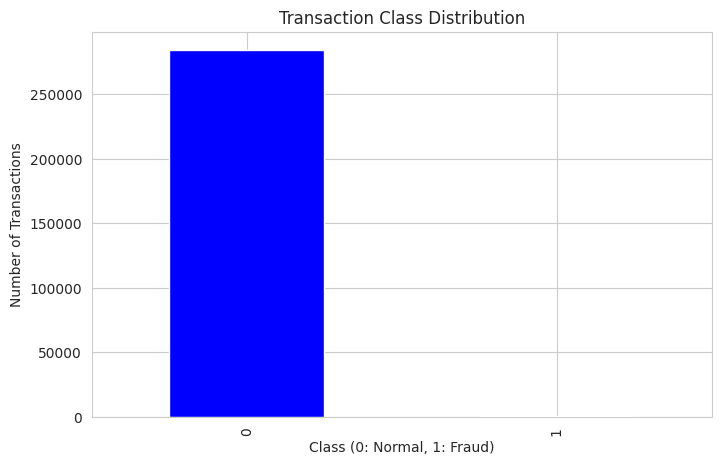

In [3]:
# Load the dataset
aml_df = pd.read_csv('/content/drive/MyDrive/Dataset/creditcard.csv')

# Display basic information about the dataset
print("\nDataset Overview:")
print("="*50)
aml_df.info()

# Check for missing values
missing_values = aml_df.isnull().sum()
print("\nMissing Values Check:")
print("="*50)
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found")

# Display class distribution
class_distribution = aml_df['Class'].value_counts()
print("\nClass Distribution:")
print("="*50)
print(class_distribution)
print(f"\nFraud cases: {class_distribution[1]/len(aml_df)*100:.3f}% of total transactions")

# Visualize class distribution
plt.figure(figsize=(8, 5))
class_distribution.plot(kind='bar', color=['blue', 'red'])
plt.title('Transaction Class Distribution')
plt.xlabel('Class (0: Normal, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.show()

## Feature Analysis and Distribution
Analyzes the distribution of key features (Amount and Time) and their
relationships with transaction classes. This analysis guides our feature
engineering decisions.


Transaction Amount Statistics:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


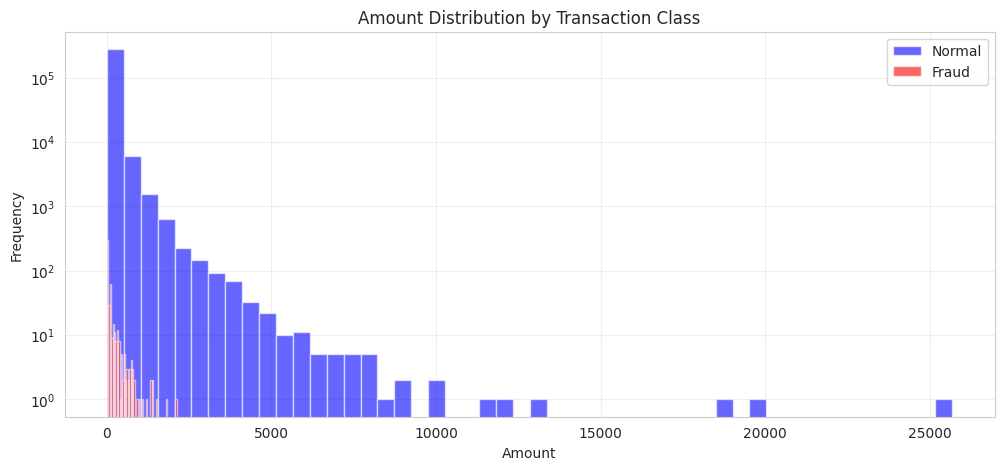


Transaction Time Statistics:
          count          mean           std    min      25%      50%  \
Class                                                                  
0      284315.0  94838.202258  47484.015786    0.0  54230.0  84711.0   
1         492.0  80746.806911  47835.365138  406.0  41241.5  75568.5   

            75%       max  
Class                      
0      139333.0  172792.0  
1      128483.0  170348.0  


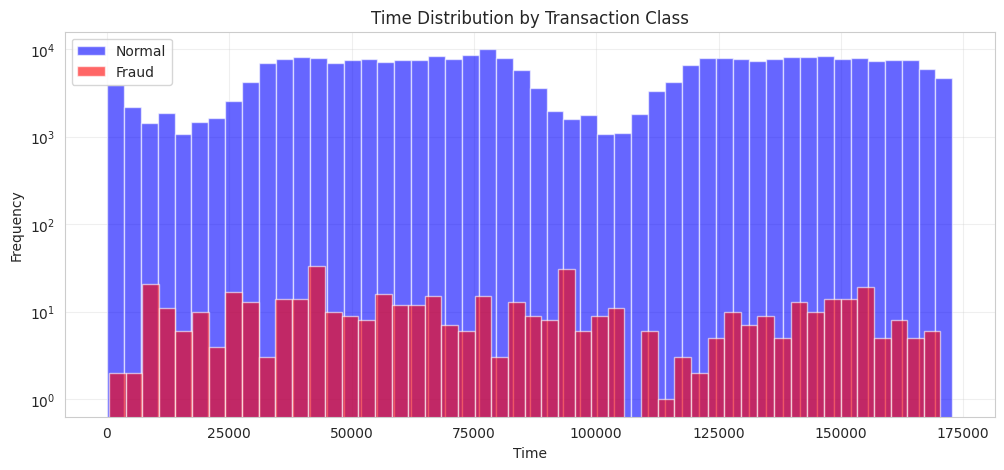

In [4]:
def plot_feature_distribution(df, feature, log_scale=False):
    """Helper function to plot feature distributions by class"""
    plt.figure(figsize=(12, 5))

    # Plot distributions for each class
    plt.hist(df[df['Class'] == 0][feature], bins=50,
             alpha=0.6, label='Normal', color='blue')
    plt.hist(df[df['Class'] == 1][feature], bins=50,
             alpha=0.6, label='Fraud', color='red')

    plt.title(f'{feature} Distribution by Transaction Class')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    if log_scale:
        plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Analyze Amount distribution
print("\nTransaction Amount Statistics:")
print("="*50)
print(aml_df.groupby('Class')['Amount'].describe())
plot_feature_distribution(aml_df, 'Amount', log_scale=True)

# Analyze Time distribution
print("\nTransaction Time Statistics:")
print("="*50)
print(aml_df.groupby('Class')['Time'].describe())
plot_feature_distribution(aml_df, 'Time', log_scale=True)

## Data Preprocessing and Feature Engineering
Implements data preprocessing steps including feature scaling and
class imbalance handling. This section prepares the data for
model training.

In [5]:
# Code partially generated with assistance from ChatGPT, an AI language model by OpenAI.
# Citation: ChatGPT, OpenAI, 2024.

# Initialize scaler
scaler = StandardScaler()

# Scale Amount and Time features
scaled_features = scaler.fit_transform(aml_df[['Amount', 'Time']])
scaled_features_df = pd.DataFrame(
    scaled_features,
    columns=['Scaled_Amount', 'Scaled_Time']
)

# Create preprocessed dataset
aml_df_scaled = pd.concat(
    [aml_df.drop(columns=['Amount', 'Time']), scaled_features_df],
    axis=1
)

# Split features and target
X = aml_df_scaled.drop(columns=['Class'])
y = aml_df_scaled['Class']

# Create train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Display split sizes
print("\nDataset Split Sizes:")
print("="*50)
print(f"Training set: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")


Dataset Split Sizes:
Training set: 170884 (60.0%)
Validation set: 56961 (20.0%)
Test set: 56962 (20.0%)


## Initial Random Forest Implementation
Implements the base Random Forest model to establish baseline performance
before incorporating clustering. This aligns with our methodology of
progressively enhancing the model's capabilities.


Base Random Forest Model Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.93      0.68      0.79        98

    accuracy                           1.00     56961
   macro avg       0.97      0.84      0.89     56961
weighted avg       1.00      1.00      1.00     56961


Top 10 Important Features:
   Feature  Importance
13     V14    0.205737
9      V10    0.120896
16     V17    0.110727
3       V4    0.098268
11     V12    0.076298
10     V11    0.072720
2       V3    0.067119
15     V16    0.043759
1       V2    0.023213
6       V7    0.020429


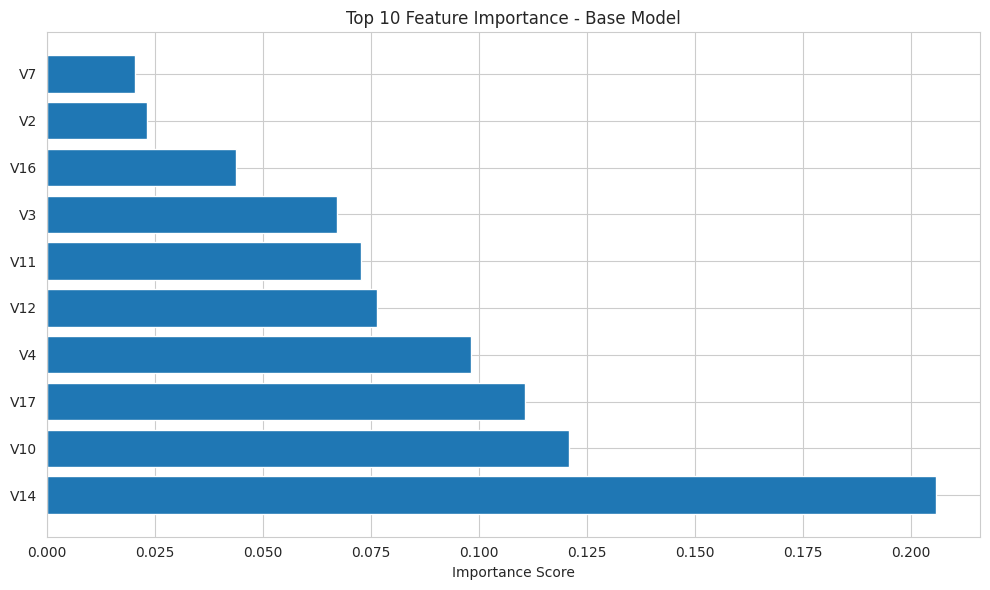

In [6]:
# Initialize base Random Forest model
rf_base_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

# Train base model
rf_base_model.fit(X_train, y_train)

# Evaluate base model
y_val_pred_base = rf_base_model.predict(X_val)
print("\nBase Random Forest Model Performance:")
print("="*50)
print(classification_report(y_val, y_val_pred_base))

# Get feature importance for clustering
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_base_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Display and plot top features
print("\nTop 10 Important Features:")
print("="*50)
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['Feature'],
         feature_importance.head(10)['Importance'])
plt.title('Top 10 Feature Importance - Base Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Class Balancing Implementation
Addresses the severe class imbalance in the dataset using SMOTE technique.
This step is crucial for improving model performance on minority class (fraud) detection.
Original ratio: 0.172% fraud cases


Original Class Distribution:
Training set: Counter({0: 170589, 1: 295})
Validation set: Counter({0: 56863, 1: 98})
Test set: Counter({0: 56863, 1: 99})

Balanced Class Distribution:
Training set: Counter({0: 170589, 1: 170589})
Validation set: Counter({1: 56863, 0: 56863})
Test set: Counter({0: 56863, 1: 56863})


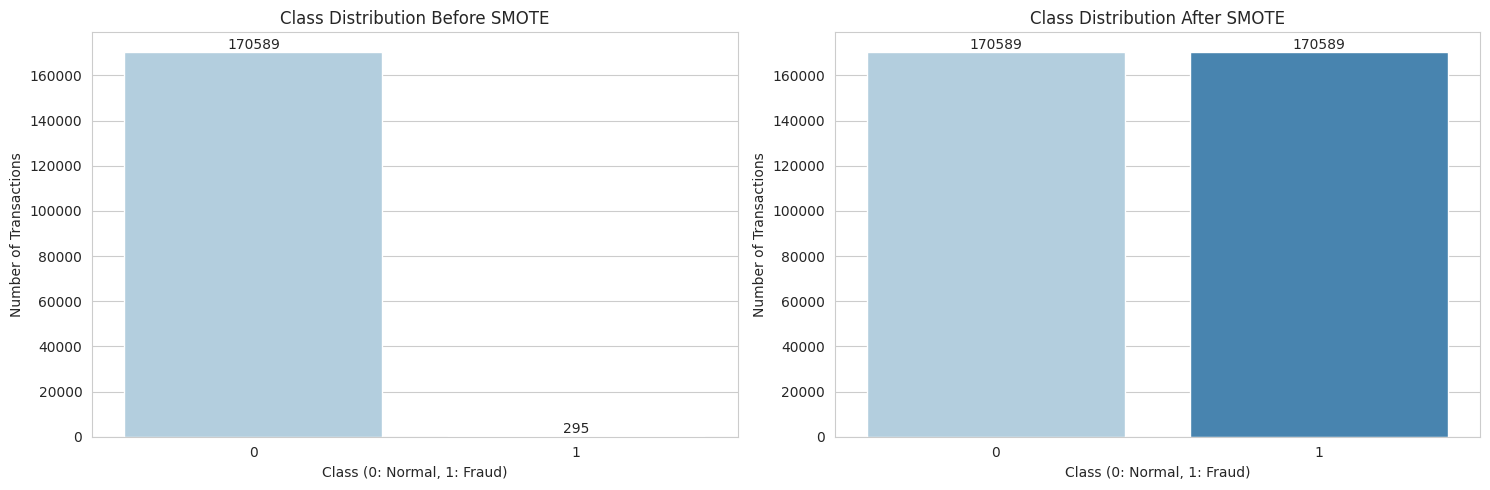

Saved balanced train dataset
Saved balanced val dataset
Saved balanced test dataset


In [7]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Display original class distribution
print("\nOriginal Class Distribution:")
print("="*50)
print("Training set:", Counter(y_train))
print("Validation set:", Counter(y_val))
print("Test set:", Counter(y_test))

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to training set
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Apply SMOTE to validation and test sets
X_val_balanced, y_val_balanced = smote.fit_resample(X_val, y_val)
X_test_balanced, y_test_balanced = smote.fit_resample(X_test, y_test)

# Display balanced class distribution
print("\nBalanced Class Distribution:")
print("="*50)
print("Training set:", Counter(y_train_balanced))
print("Validation set:", Counter(y_val_balanced))
print("Test set:", Counter(y_test_balanced))

# Visualize class distribution before and after SMOTE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Before SMOTE
sns.countplot(data=pd.DataFrame(y_train, columns=['Class']),
             x='Class', ax=ax1, palette='Blues')
ax1.set_title('Class Distribution Before SMOTE')
ax1.set_xlabel('Class (0: Normal, 1: Fraud)')
ax1.set_ylabel('Number of Transactions')
for i in ax1.containers:
    ax1.bar_label(i)

# After SMOTE
sns.countplot(data=pd.DataFrame(y_train_balanced, columns=['Class']),
             x='Class', ax=ax2, palette='Blues')
ax2.set_title('Class Distribution After SMOTE')
ax2.set_xlabel('Class (0: Normal, 1: Fraud)')
ax2.set_ylabel('Number of Transactions')
for i in ax2.containers:
    ax2.bar_label(i)

plt.tight_layout()
plt.show()

# Save balanced datasets for later use
balanced_datasets = {
    'train': (X_train_balanced, y_train_balanced),
    'val': (X_val_balanced, y_val_balanced),
    'test': (X_test_balanced, y_test_balanced)
}

# Create DataFrames with balanced data
for name, (X, y) in balanced_datasets.items():
    balanced_df = pd.DataFrame(X, columns=X_train.columns)
    balanced_df['Class'] = y
    balanced_df.to_csv(f'/content/aml_df_{name}_balanced.csv', index=False)
    print(f"Saved balanced {name} dataset")

## K-means Clustering Implementation
Implements K-means clustering using selected features from Random Forest
importance analysis. This forms the unsupervised learning component of
our hybrid approach.

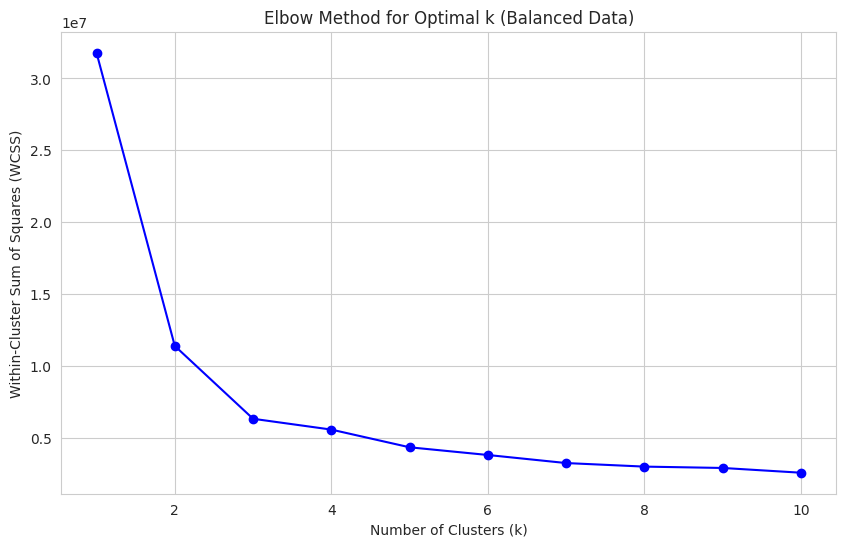


Cluster Distribution in Balanced Training Set:
Class       0       1     All
row_0                        
0      170569   95353  265922
1          20   75236   75256
All    170589  170589  341178


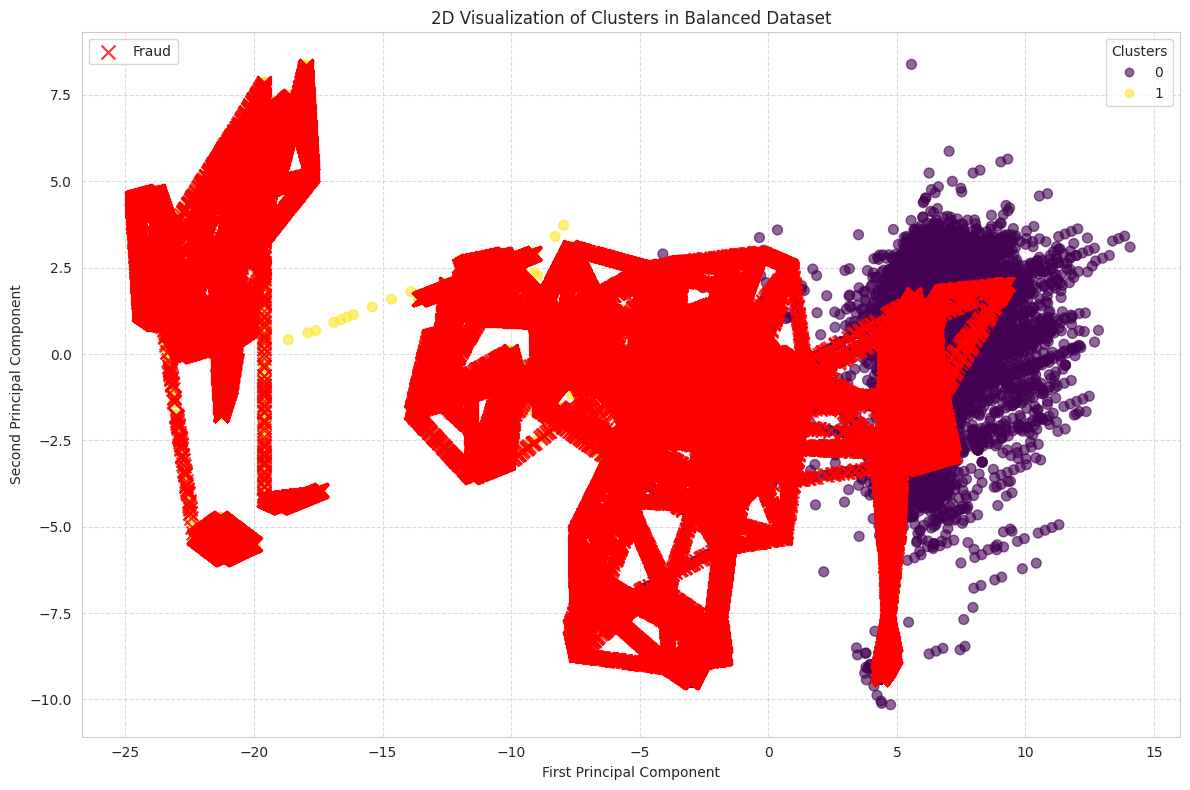

In [8]:

from sklearn.cluster import KMeans

# Create balanced feature set for clustering
def prepare_cluster_features(X_data, selected_features):
    """Prepare selected features for clustering"""
    return X_data[selected_features]

# Select features for clustering based on importance
selected_features = ['Scaled_Amount', 'Scaled_Time', 'V4', 'V10', 'V17', 'V14']

# Prepare balanced datasets for clustering
X_cluster_balanced = prepare_cluster_features(X_train_balanced, selected_features)

# Determine optimal number of clusters using elbow method
wcss = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster_balanced)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, wcss, marker='o', color='blue')
plt.title('Elbow Method for Optimal k (Balanced Data)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

# Implement K-means with optimal clusters
optimal_k = 2  # Based on elbow curve
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42)

# Fit on balanced training data
cluster_labels_train = kmeans_model.fit_predict(X_cluster_balanced)

# Apply clustering to validation and test sets
X_cluster_val = prepare_cluster_features(X_val_balanced, selected_features)
X_cluster_test = prepare_cluster_features(X_test_balanced, selected_features)

cluster_labels_val = kmeans_model.predict(X_cluster_val)
cluster_labels_test = kmeans_model.predict(X_cluster_test)

# Analyze cluster distribution in balanced data
print("\nCluster Distribution in Balanced Training Set:")
print("="*50)
cluster_dist = pd.crosstab(
    cluster_labels_train,
    y_train_balanced,
    margins=True
)
print(cluster_dist)

# Visualize clusters in 2D using PCA
from sklearn.decomposition import PCA

# Apply PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_balanced)

# Create visualization DataFrame
plot_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
plot_df['Cluster'] = cluster_labels_train
plot_df['Class'] = y_train_balanced

# Plot clusters
plt.figure(figsize=(12, 8))

# Plot points colored by cluster
scatter = plt.scatter(plot_df['PC1'],
                     plot_df['PC2'],
                     c=plot_df['Cluster'],
                     cmap='viridis',
                     alpha=0.6,
                     s=50)

# Highlight fraud cases
fraud_points = plot_df[plot_df['Class'] == 1]
plt.scatter(fraud_points['PC1'],
           fraud_points['PC2'],
           color='red',
           marker='x',
           s=100,
           label='Fraud',
           alpha=0.8)

plt.title('2D Visualization of Clusters in Balanced Dataset')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

# Add legend
legend1 = plt.legend(*scatter.legend_elements(),
                    title="Clusters",
                    loc="upper right")
plt.legend(loc="upper left")
plt.gca().add_artist(legend1)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Save cluster information for model training
X_train_balanced['Cluster'] = cluster_labels_train
X_val_balanced['Cluster'] = cluster_labels_val
X_test_balanced['Cluster'] = cluster_labels_test

print("\nExplained variance ratio of PCA components:")
print("="*50)
print(f"PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Total: {sum(pca.explained_variance_ratio_):.3f}")


Explained variance ratio of PCA components:
PC1: 0.847
PC2: 0.074
Total: 0.921


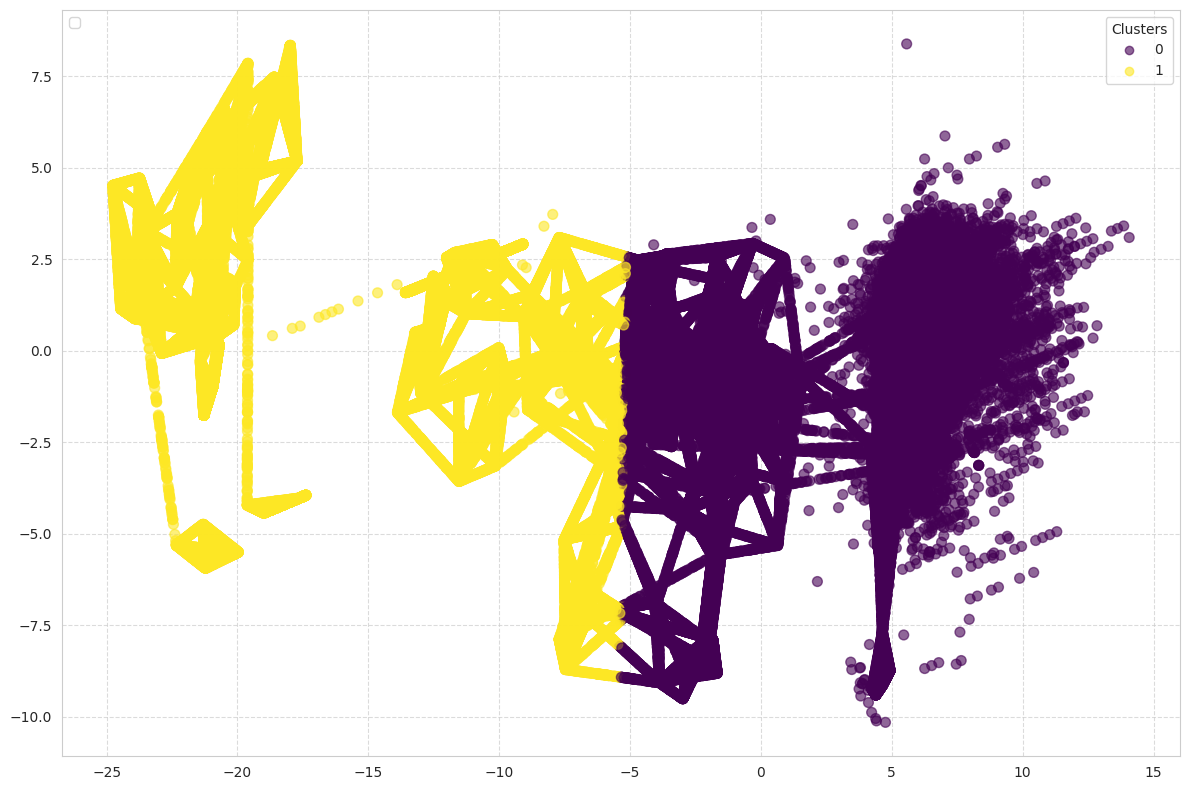

In [9]:
# Visualization code for clustered data (code partially generated by Gemini (2024)

# Plot clusters
plt.figure(figsize=(12, 8))

# Plot points colored by cluster
scatter = plt.scatter(plot_df['PC1'],
                     plot_df['PC2'],
                     c=plot_df['Cluster'],
                     cmap='viridis',
                     alpha=0.6,
                     s=50)


# Add legend
legend1 = plt.legend(*scatter.legend_elements(),
                    title="Clusters",
                    loc="upper right")
plt.legend(loc="upper left")
plt.gca().add_artist(legend1)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Enhanced Random Forest with Clustering
Implements the enhanced Random Forest model incorporating clustering
information, following our hybrid approach methodology.


Enhanced Random Forest Performance (Balanced Validation Set):
              precision    recall  f1-score   support

           0       0.86      1.00      0.93     56863
           1       1.00      0.84      0.91     56863

    accuracy                           0.92    113726
   macro avg       0.93      0.92      0.92    113726
weighted avg       0.93      0.92      0.92    113726


AUC-ROC Score: 0.9834


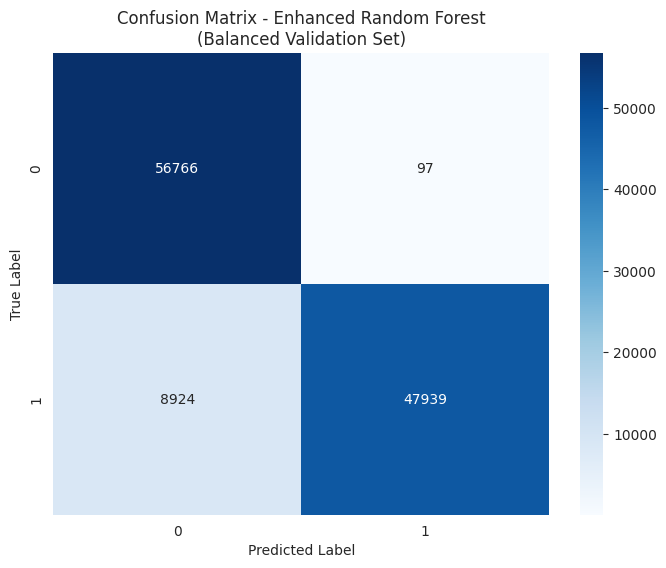

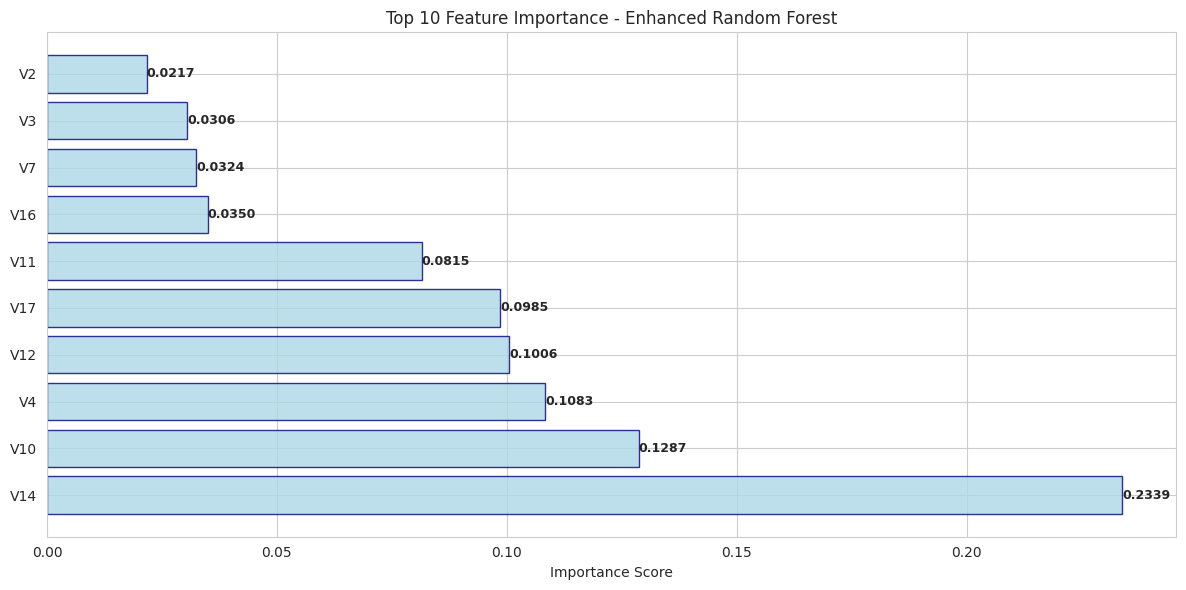


Prediction Analysis by Cluster:

Cluster 1 Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       1.00      1.00      1.00     24406

    accuracy                           1.00     24418
   macro avg       0.50      0.50      0.50     24418
weighted avg       1.00      1.00      1.00     24418


Cluster 0 Results:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93     56851
           1       1.00      0.73      0.84     32457

    accuracy                           0.90     89308
   macro avg       0.93      0.86      0.88     89308
weighted avg       0.91      0.90      0.89     89308



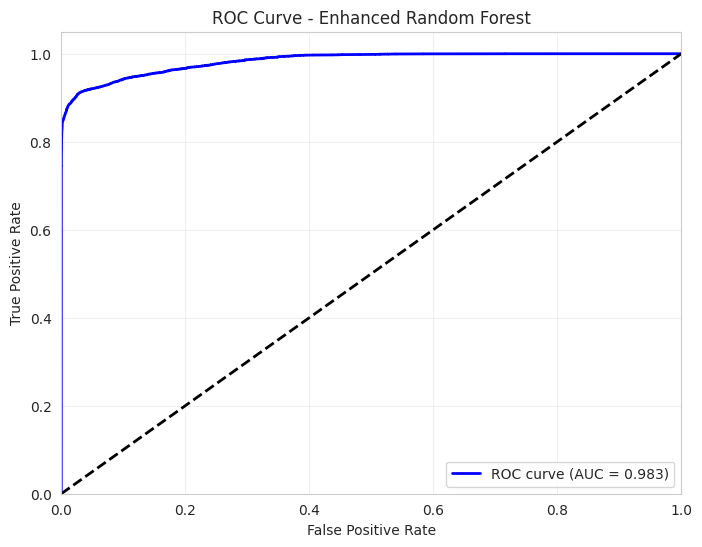

In [10]:
# Machine learning components
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)
# Initialize enhanced Random Forest model
rf_enhanced_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train model with balanced data including cluster information
rf_enhanced_model.fit(X_train_balanced, y_train_balanced)

# Generate predictions
y_val_pred = rf_enhanced_model.predict(X_val_balanced)
y_val_pred_proba = rf_enhanced_model.predict_proba(X_val_balanced)[:, 1]

# Evaluate model performance
print("\nEnhanced Random Forest Performance (Balanced Validation Set):")
print("="*50)
print(classification_report(y_val_balanced, y_val_pred))
print(f"\nAUC-ROC Score: {roc_auc_score(y_val_balanced, y_val_pred_proba):.4f}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val_balanced, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Enhanced Random Forest\n(Balanced Validation Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Analyze feature importance including cluster information
feature_importance = pd.DataFrame({
    'Feature': X_train_balanced.columns,
    'Importance': rf_enhanced_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(feature_importance.head(10)['Feature'],
         feature_importance.head(10)['Importance'],
         color='lightblue',
         edgecolor='navy',
         alpha=0.8)

plt.title('Top 10 Feature Importance - Enhanced Random Forest')
plt.xlabel('Importance Score')

# Add value labels
for i, v in enumerate(feature_importance.head(10)['Importance']):
    plt.text(v, i, f'{v:.4f}',
             va='center',
             fontweight='bold',
             fontsize=9)

plt.tight_layout()
plt.show()

# Analyze prediction distribution by cluster
prediction_analysis = pd.DataFrame({
    'True_Class': y_val_balanced,
    'Predicted_Class': y_val_pred,
    'Cluster': X_val_balanced['Cluster']
})

print("\nPrediction Analysis by Cluster:")
print("="*50)
for cluster in prediction_analysis['Cluster'].unique():
    cluster_data = prediction_analysis[prediction_analysis['Cluster'] == cluster]
    print(f"\nCluster {cluster} Results:")
    print(classification_report(cluster_data['True_Class'],
                              cluster_data['Predicted_Class']))

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_val_balanced, y_val_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr,
         color='blue',
         lw=2,
         label=f'ROC curve (AUC = {roc_auc_score(y_val_balanced, y_val_pred_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Enhanced Random Forest')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Save model performance metrics
rf_metrics = {
    'accuracy': accuracy_score(y_val_balanced, y_val_pred),
    'auc_roc': roc_auc_score(y_val_balanced, y_val_pred_proba),
    'confusion_matrix': cm,
    'feature_importance': feature_importance,
    'classification_report': classification_report(y_val_balanced, y_val_pred)
}


XGBoost Model Performance (Balanced Validation Set):
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     56863
           1       1.00      0.85      0.92     56863

    accuracy                           0.92    113726
   macro avg       0.93      0.92      0.92    113726
weighted avg       0.93      0.92      0.92    113726


AUC-ROC Score: 0.9855


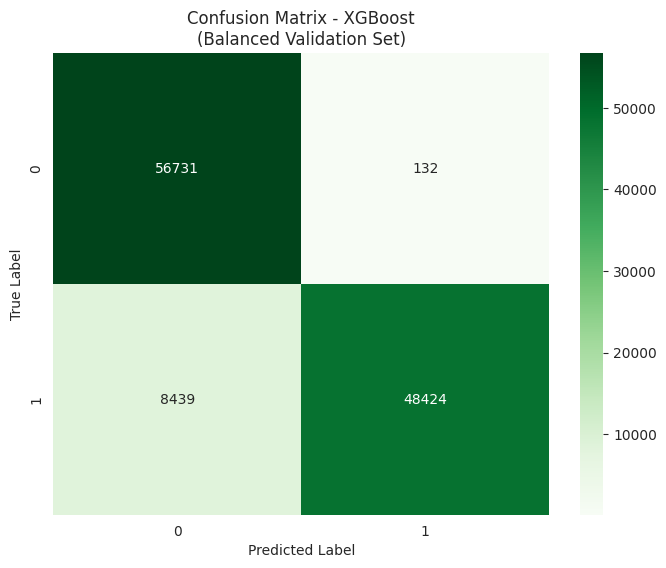

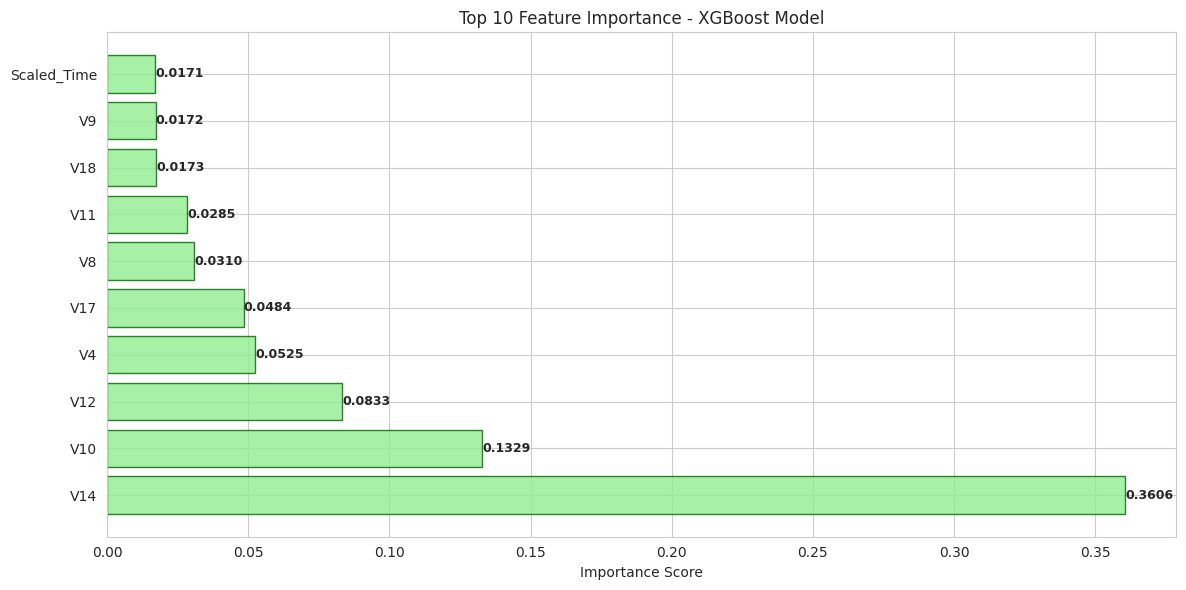


XGBoost Prediction Analysis by Cluster:

Cluster 1 Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       1.00      1.00      1.00     24406

    accuracy                           1.00     24418
   macro avg       0.50      0.50      0.50     24418
weighted avg       1.00      1.00      1.00     24418


Cluster 0 Results:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     56851
           1       1.00      0.74      0.85     32457

    accuracy                           0.90     89308
   macro avg       0.93      0.87      0.89     89308
weighted avg       0.92      0.90      0.90     89308



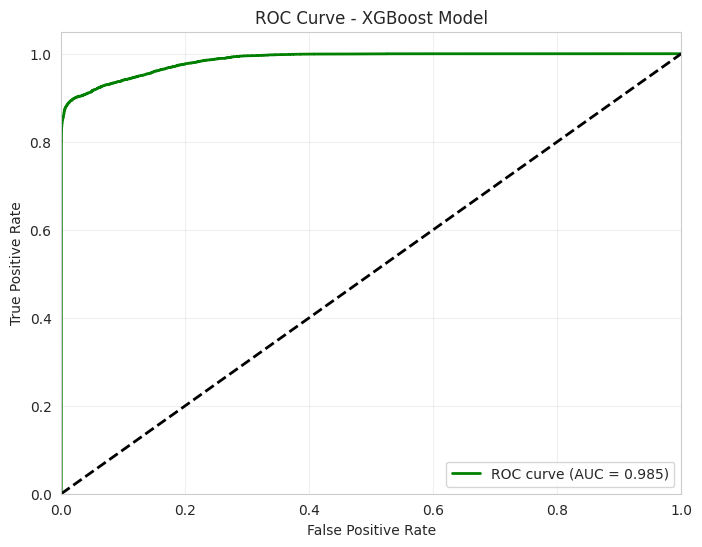


Top 10 Features Comparison:
    Feature  XGBoost_Importance  RF_Importance
        V14            0.360606       0.233850
        V10            0.132931       0.128708
        V12            0.083290       0.100572
         V4            0.052549       0.108321
        V17            0.048369       0.098510
         V8            0.030966       0.010141
        V11            0.028483       0.081511
        V18            0.017335       0.016385
         V9            0.017217       0.010441
Scaled_Time            0.017062       0.005125


In [11]:
# Required imports
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize XGBoost with optimized parameters
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    scale_pos_weight=1,
    random_state=42,
    n_jobs=-1
)

# Train XGBoost on balanced data
xgb_model.fit(X_train_balanced, y_train_balanced)

# Generate predictions
y_val_pred_xgb = xgb_model.predict(X_val_balanced)
y_val_pred_proba_xgb = xgb_model.predict_proba(X_val_balanced)[:, 1]

# Print model performance
print("\nXGBoost Model Performance (Balanced Validation Set):")
print("="*50)
print(classification_report(y_val_balanced, y_val_pred_xgb))
print(f"\nAUC-ROC Score: {roc_auc_score(y_val_balanced, y_val_pred_proba_xgb):.4f}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
cm_xgb = confusion_matrix(y_val_balanced, y_val_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - XGBoost\n(Balanced Validation Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Feature importance analysis
xgb_importance = pd.DataFrame({
    'Feature': X_train_balanced.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(xgb_importance.head(10)['Feature'],
         xgb_importance.head(10)['Importance'],
         color='lightgreen',
         edgecolor='darkgreen',
         alpha=0.8)

plt.title('Top 10 Feature Importance - XGBoost Model')
plt.xlabel('Importance Score')

# Add value labels
for i, v in enumerate(xgb_importance.head(10)['Importance']):
    plt.text(v, i, f'{v:.4f}',
             va='center',
             fontweight='bold',
             fontsize=9)

plt.tight_layout()
plt.show()

# Analyze prediction distribution by cluster
xgb_prediction_analysis = pd.DataFrame({
    'True_Class': y_val_balanced,
    'Predicted_Class': y_val_pred_xgb,
    'Cluster': X_val_balanced['Cluster']
})

print("\nXGBoost Prediction Analysis by Cluster:")
print("="*50)
for cluster in xgb_prediction_analysis['Cluster'].unique():
    cluster_data = xgb_prediction_analysis[xgb_prediction_analysis['Cluster'] == cluster]
    print(f"\nCluster {cluster} Results:")
    print(classification_report(cluster_data['True_Class'],
                              cluster_data['Predicted_Class']))

# Plot ROC curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_val_balanced, y_val_pred_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb,
         color='green',
         lw=2,
         label=f'ROC curve (AUC = {roc_auc_score(y_val_balanced, y_val_pred_proba_xgb):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Model')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Save XGBoost performance metrics
xgb_metrics = {
    'accuracy': accuracy_score(y_val_balanced, y_val_pred_xgb),
    'auc_roc': roc_auc_score(y_val_balanced, y_val_pred_proba_xgb),
    'confusion_matrix': cm_xgb,
    'feature_importance': xgb_importance,
    'classification_report': classification_report(y_val_balanced, y_val_pred_xgb)
}

# Compare feature importance rankings between RF and XGBoost
print("\nTop 10 Features Comparison:")
print("="*50)
comparison_df = pd.DataFrame({
    'Feature': xgb_importance['Feature'].head(10),
    'XGBoost_Importance': xgb_importance['Importance'].head(10),
    'RF_Importance': [rf_metrics['feature_importance'][rf_metrics['feature_importance']['Feature'] == feat]['Importance'].iloc[0]
                     for feat in xgb_importance['Feature'].head(10)]
})
print(comparison_df.to_string(index=False))

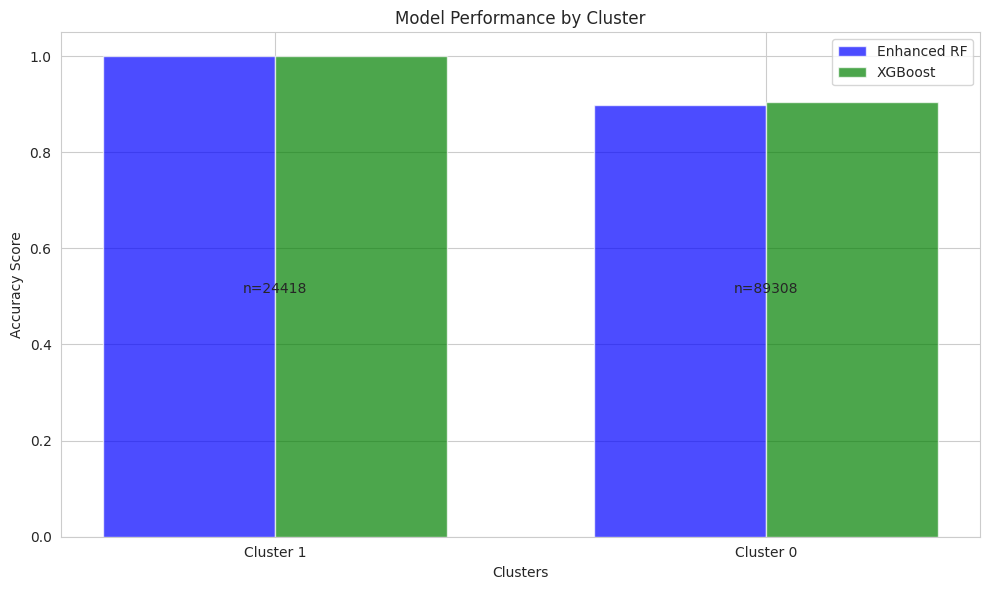

In [12]:
# Create performance analysis by cluster
cluster_metrics = []

for cluster in X_val_balanced['Cluster'].unique():
    cluster_mask = X_val_balanced['Cluster'] == cluster
    X_cluster = X_val_balanced[cluster_mask]
    y_cluster = y_val_balanced[cluster_mask]

    # RF predictions
    rf_pred = rf_enhanced_model.predict(X_cluster)
    rf_acc = accuracy_score(y_cluster, rf_pred)

    # XGB predictions
    xgb_pred = xgb_model.predict(X_cluster)
    xgb_acc = accuracy_score(y_cluster, xgb_pred)

    cluster_metrics.append({
        'Cluster': f'Cluster {cluster}',
        'RF_Accuracy': rf_acc,
        'XGB_Accuracy': xgb_acc,
        'Sample_Size': sum(cluster_mask)
    })

# Convert to DataFrame
cluster_performance = pd.DataFrame(cluster_metrics)

# Create visualization
plt.figure(figsize=(10, 6))
x = range(len(cluster_performance))
width = 0.35

plt.bar([i - width/2 for i in x], cluster_performance['RF_Accuracy'],
        width, label='Enhanced RF', color='blue', alpha=0.7)
plt.bar([i + width/2 for i in x], cluster_performance['XGB_Accuracy'],
        width, label='XGBoost', color='green', alpha=0.7)

plt.xlabel('Clusters')
plt.ylabel('Accuracy Score')
plt.title('Model Performance by Cluster')
plt.xticks(x, cluster_performance['Cluster'])
plt.legend()

# Add sample size annotations
for i, row in enumerate(cluster_performance.itertuples()):
    plt.text(i, 0.5, f'n={row.Sample_Size}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

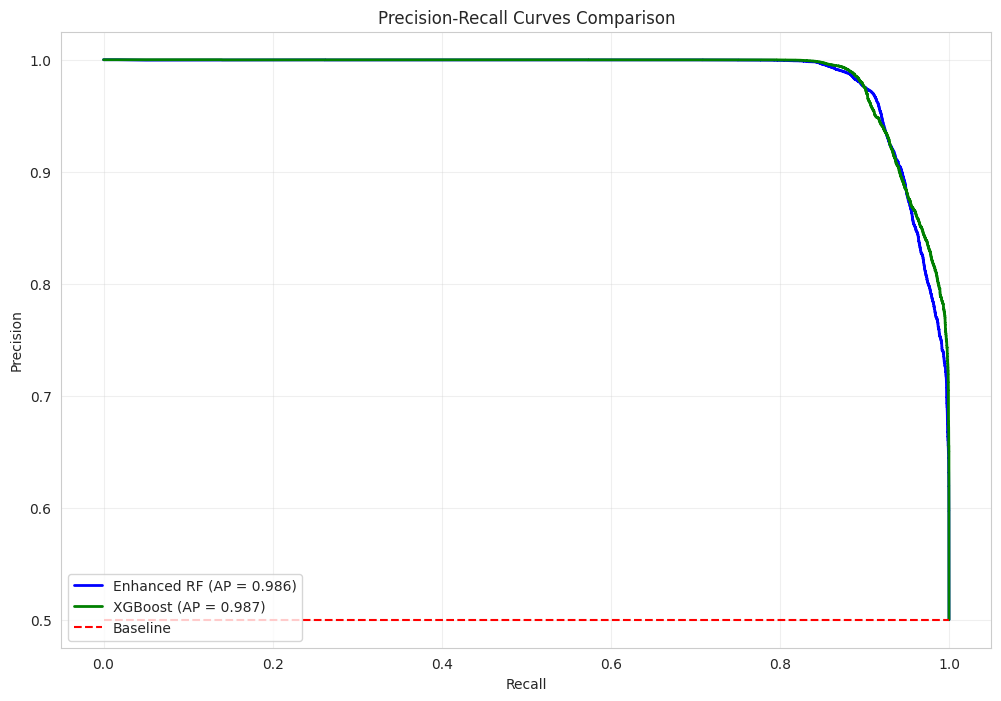

In [13]:
# Create Precision-Recall curve comparison
from sklearn.metrics import precision_recall_curve, average_precision_score
plt.figure(figsize=(12, 8))

# Random Forest Enhanced
precision_rf, recall_rf, _ = precision_recall_curve(y_val_balanced, y_val_pred_proba)
avg_precision_rf = average_precision_score(y_val_balanced, y_val_pred_proba)
plt.plot(recall_rf, precision_rf,
         color='blue',
         lw=2,
         label=f'Enhanced RF (AP = {avg_precision_rf:.3f})')

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_val_balanced, y_val_pred_proba_xgb)
avg_precision_xgb = average_precision_score(y_val_balanced, y_val_pred_proba_xgb)
plt.plot(recall_xgb, precision_xgb,
         color='green',
         lw=2,
         label=f'XGBoost (AP = {avg_precision_xgb:.3f})')

# Add baseline
plt.plot([0, 1], [0.5, 0.5],
         color='red',
         linestyle='--',
         label='Baseline')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves Comparison')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

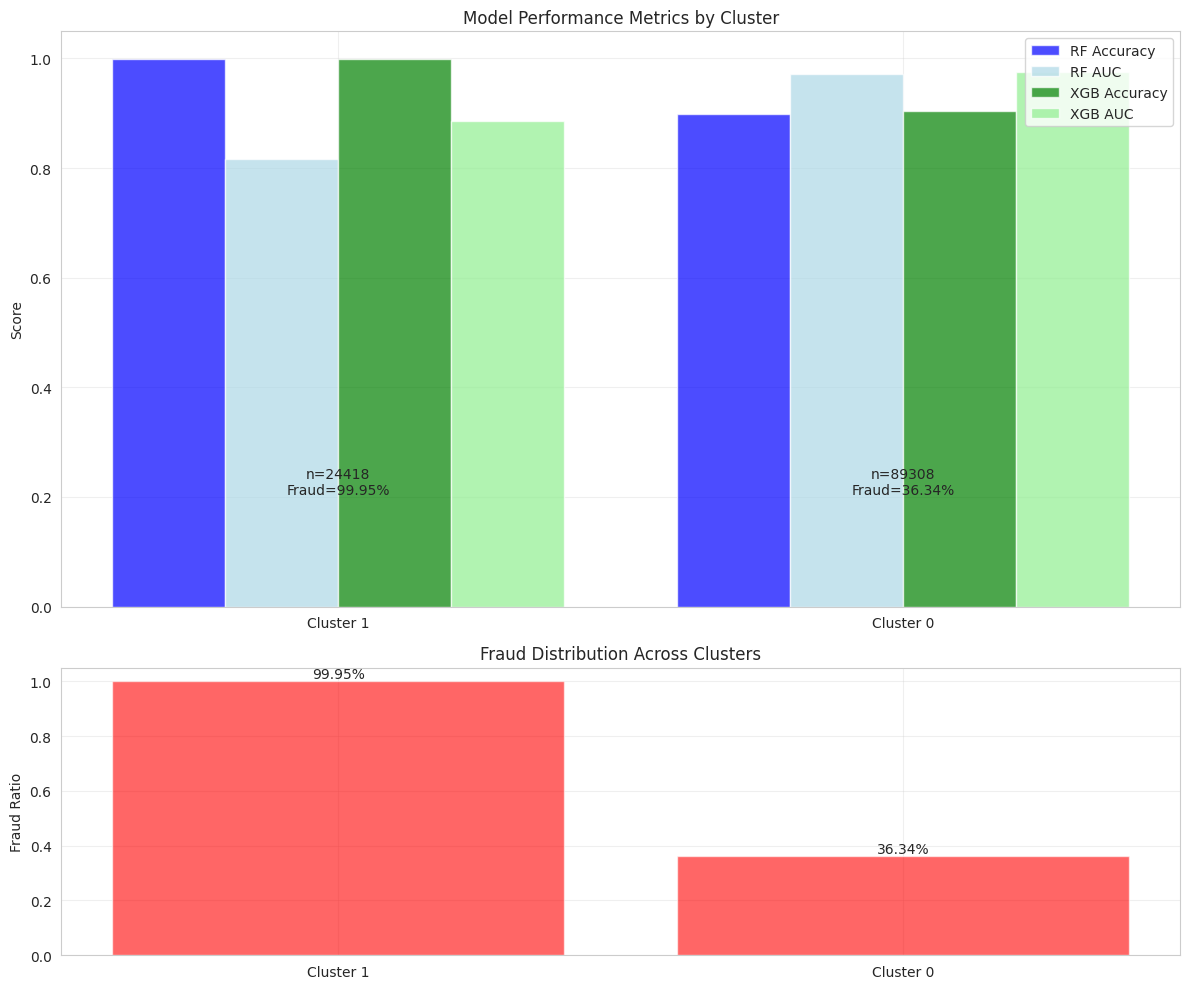


Detailed Cluster Performance Metrics:

Cluster 1:
Sample Size: 24418
Fraud Ratio: 99.95%
RF  - Accuracy: 1.000, AUC: 0.817
XGB - Accuracy: 1.000, AUC: 0.887

Cluster 0:
Sample Size: 89308
Fraud Ratio: 36.34%
RF  - Accuracy: 0.899, AUC: 0.971
XGB - Accuracy: 0.904, AUC: 0.975


In [14]:
# Create comprehensive cluster performance analysis
cluster_metrics = []

for cluster in X_val_balanced['Cluster'].unique():
    cluster_mask = X_val_balanced['Cluster'] == cluster
    X_cluster = X_val_balanced[cluster_mask]
    y_cluster = y_val_balanced[cluster_mask]

    # RF predictions and metrics
    rf_pred = rf_enhanced_model.predict(X_cluster)
    rf_pred_proba = rf_enhanced_model.predict_proba(X_cluster)[:, 1]
    rf_acc = accuracy_score(y_cluster, rf_pred)
    rf_auc = roc_auc_score(y_cluster, rf_pred_proba)

    # XGB predictions and metrics
    xgb_pred = xgb_model.predict(X_cluster)
    xgb_pred_proba = xgb_model.predict_proba(X_cluster)[:, 1]
    xgb_acc = accuracy_score(y_cluster, xgb_pred)
    xgb_auc = roc_auc_score(y_cluster, xgb_pred_proba)

    # Calculate fraud ratio in cluster
    fraud_ratio = (y_cluster == 1).mean()

    cluster_metrics.append({
        'Cluster': f'Cluster {cluster}',
        'RF_Accuracy': rf_acc,
        'RF_AUC': rf_auc,
        'XGB_Accuracy': xgb_acc,
        'XGB_AUC': xgb_auc,
        'Fraud_Ratio': fraud_ratio,
        'Sample_Size': sum(cluster_mask)
    })

# Convert to DataFrame
cluster_performance = pd.DataFrame(cluster_metrics)

# Create enhanced visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[2, 1])

# Plot 1: Model Performance Comparison
x = range(len(cluster_performance))
width = 0.2

# Accuracy bars
ax1.bar([i - width*1.5 for i in x], cluster_performance['RF_Accuracy'],
        width, label='RF Accuracy', color='blue', alpha=0.7)
ax1.bar([i - width/2 for i in x], cluster_performance['RF_AUC'],
        width, label='RF AUC', color='lightblue', alpha=0.7)
ax1.bar([i + width/2 for i in x], cluster_performance['XGB_Accuracy'],
        width, label='XGB Accuracy', color='green', alpha=0.7)
ax1.bar([i + width*1.5 for i in x], cluster_performance['XGB_AUC'],
        width, label='XGB AUC', color='lightgreen', alpha=0.7)

# Customize first plot
ax1.set_ylabel('Score')
ax1.set_title('Model Performance Metrics by Cluster')
ax1.set_xticks(x)
ax1.set_xticklabels(cluster_performance['Cluster'])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add sample size and fraud ratio annotations
for i, row in enumerate(cluster_performance.itertuples()):
    ax1.text(i, 0.2, f'n={row.Sample_Size}\nFraud={row.Fraud_Ratio:.2%}',
             ha='center', va='bottom')

# Plot 2: Fraud Distribution
fraud_bars = ax2.bar(cluster_performance['Cluster'],
                    cluster_performance['Fraud_Ratio'],
                    color='red', alpha=0.6)
ax2.set_ylabel('Fraud Ratio')
ax2.set_title('Fraud Distribution Across Clusters')
ax2.grid(True, alpha=0.3)

# Add value labels
for bar in fraud_bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print detailed metrics
print("\nDetailed Cluster Performance Metrics:")
print("="*50)
for _, row in cluster_performance.iterrows():
    print(f"\n{row['Cluster']}:")
    print(f"Sample Size: {row['Sample_Size']}")
    print(f"Fraud Ratio: {row['Fraud_Ratio']:.2%}")
    print(f"RF  - Accuracy: {row['RF_Accuracy']:.3f}, AUC: {row['RF_AUC']:.3f}")
    print(f"XGB - Accuracy: {row['XGB_Accuracy']:.3f}, AUC: {row['XGB_AUC']:.3f}")

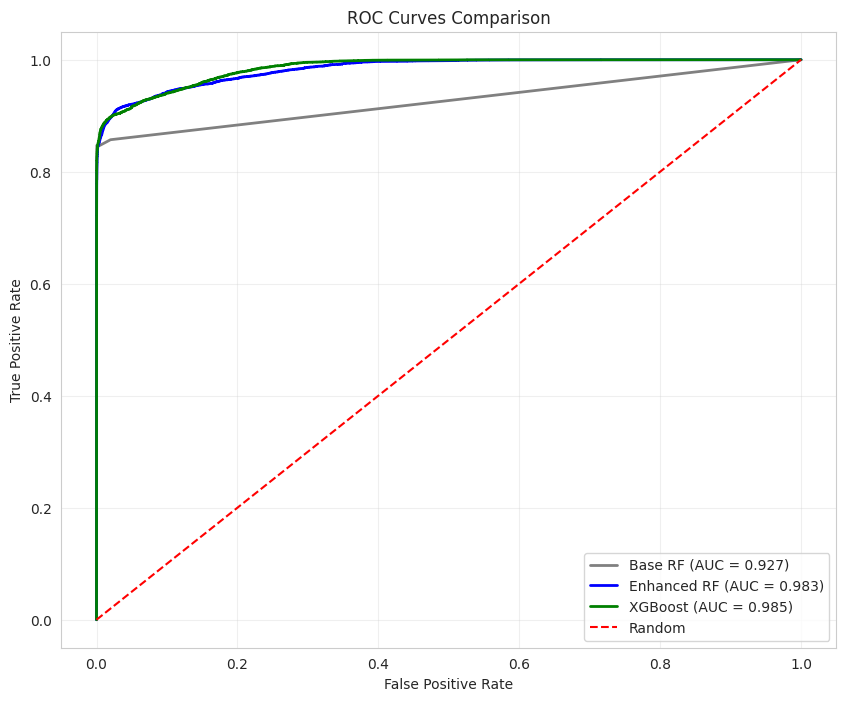

In [15]:
# Plot ROC curves comparison for all models
plt.figure(figsize=(10, 8))

# Base Random Forest (using original scaled data)
base_pred_proba = rf_base_model.predict_proba(X_val)[:, 1]
fpr_base, tpr_base, _ = roc_curve(y_val, base_pred_proba)
auc_base = roc_auc_score(y_val, base_pred_proba)
plt.plot(fpr_base, tpr_base,
         color='gray',
         lw=2,
         label=f'Base RF (AUC = {auc_base:.3f})')

# Enhanced Random Forest (using clustered data)
enhanced_pred_proba = rf_enhanced_model.predict_proba(X_val_balanced)[:, 1]
fpr_enh, tpr_enh, _ = roc_curve(y_val_balanced, enhanced_pred_proba)
auc_enh = roc_auc_score(y_val_balanced, enhanced_pred_proba)
plt.plot(fpr_enh, tpr_enh,
         color='blue',
         lw=2,
         label=f'Enhanced RF (AUC = {auc_enh:.3f})')

# XGBoost (using clustered data)
xgb_pred_proba = xgb_model.predict_proba(X_val_balanced)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_val_balanced, xgb_pred_proba)
auc_xgb = roc_auc_score(y_val_balanced, xgb_pred_proba)
plt.plot(fpr_xgb, tpr_xgb,
         color='green',
         lw=2,
         label=f'XGBoost (AUC = {auc_xgb:.3f})')

# Random baseline
plt.plot([0, 1], [0, 1],
         color='red',
         linestyle='--',
         label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

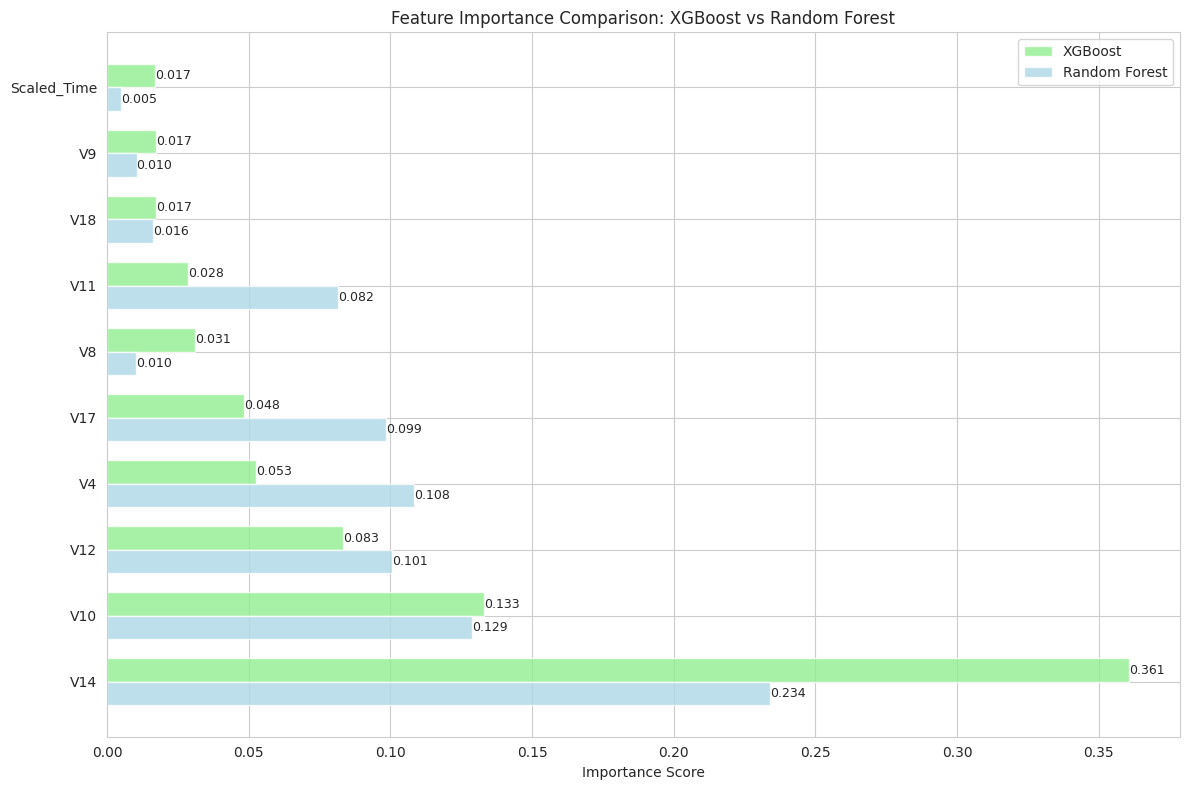

In [16]:
"""
Feature Importance Visualization
Generated using Type AI (2024) - https://type.ai
This code creates a comparative visualization of feature importance scores
between XGBoost and Random Forest models.
"""

# Create figure
plt.figure(figsize=(12, 8))

# Get top 10 features for comparison
comparison_df = pd.DataFrame({
    'Feature': xgb_importance['Feature'].head(10),
    'XGBoost': xgb_importance['Importance'].head(10),
    'Random Forest': [rf_metrics['feature_importance'][rf_metrics['feature_importance']['Feature'] == feat]['Importance'].iloc[0]
                     for feat in xgb_importance['Feature'].head(10)]
})

# Create bar positions
x = np.arange(len(comparison_df['Feature']))
width = 0.35

# Create bars
plt.barh(x + width/2, comparison_df['XGBoost'], width,
         label='XGBoost', color='lightgreen', alpha=0.8)
plt.barh(x - width/2, comparison_df['Random Forest'], width,
         label='Random Forest', color='lightblue', alpha=0.8)

# Customize plot
plt.yticks(x, comparison_df['Feature'])
plt.xlabel('Importance Score')
plt.title('Feature Importance Comparison: XGBoost vs Random Forest')
plt.legend()

# Add value labels
for i, v in enumerate(comparison_df['XGBoost']):
    plt.text(v, i + width/2, f'{v:.3f}',
             va='center', fontsize=9)
for i, v in enumerate(comparison_df['Random Forest']):
    plt.text(v, i - width/2, f'{v:.3f}',
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

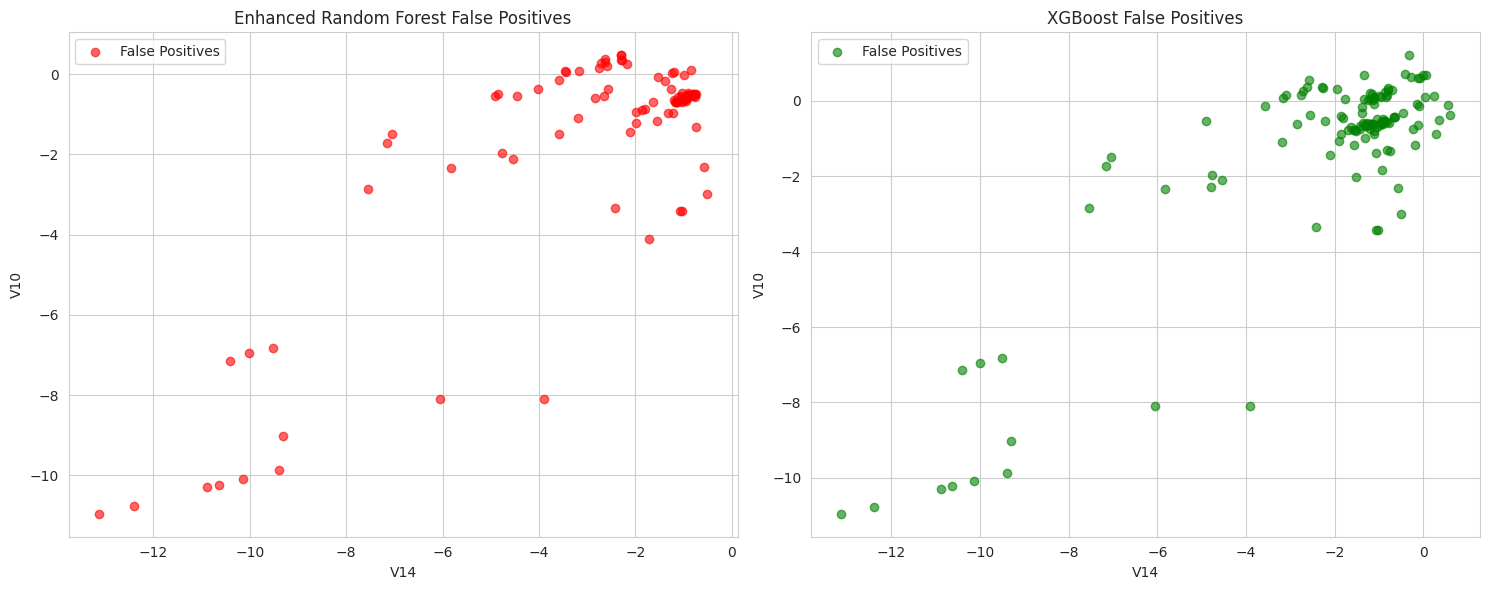

In [17]:
# Create scatter plot of false positives
plt.figure(figsize=(12, 5))

# Create subplots for RF and XGBoost
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# RF False Positives
fp_mask_rf = (y_val_balanced == 0) & (y_val_pred == 1)
ax1.scatter(X_val_balanced[fp_mask_rf]['V14'],
           X_val_balanced[fp_mask_rf]['V10'],
           c='red', alpha=0.6, label='False Positives')
ax1.set_title('Enhanced Random Forest False Positives')
ax1.set_xlabel('V14')
ax1.set_ylabel('V10')
ax1.legend()

# XGBoost False Positives
fp_mask_xgb = (y_val_balanced == 0) & (y_val_pred_xgb == 1)
ax2.scatter(X_val_balanced[fp_mask_xgb]['V14'],
           X_val_balanced[fp_mask_xgb]['V10'],
           c='green', alpha=0.6, label='False Positives')
ax2.set_title('XGBoost False Positives')
ax2.set_xlabel('V14')
ax2.set_ylabel('V10')
ax2.legend()

plt.tight_layout()


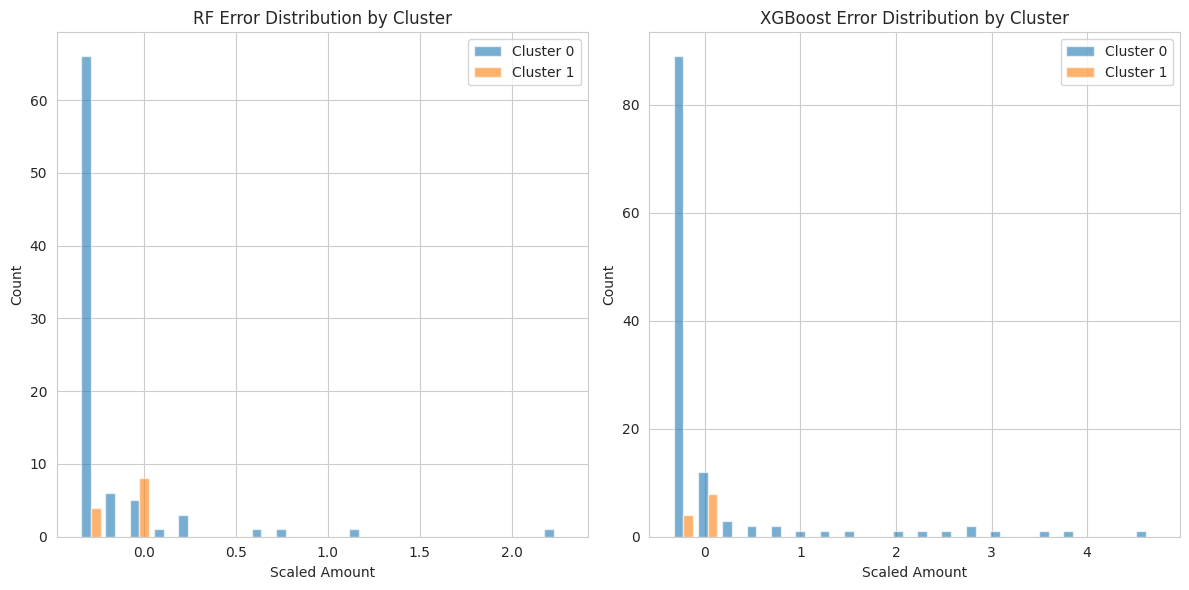

In [18]:
plt.figure(figsize=(12, 6))

# Create histogram of errors by cluster
plt.subplot(1, 2, 1)
plt.hist([X_val_balanced[fp_mask_rf & (X_val_balanced['Cluster'] == 0)]['Scaled_Amount'],
          X_val_balanced[fp_mask_rf & (X_val_balanced['Cluster'] == 1)]['Scaled_Amount']],
         label=['Cluster 0', 'Cluster 1'], bins=20, alpha=0.6)
plt.title('RF Error Distribution by Cluster')
plt.xlabel('Scaled Amount')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist([X_val_balanced[fp_mask_xgb & (X_val_balanced['Cluster'] == 0)]['Scaled_Amount'],
          X_val_balanced[fp_mask_xgb & (X_val_balanced['Cluster'] == 1)]['Scaled_Amount']],
         label=['Cluster 0', 'Cluster 1'], bins=20, alpha=0.6)
plt.title('XGBoost Error Distribution by Cluster')
plt.xlabel('Scaled Amount')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()

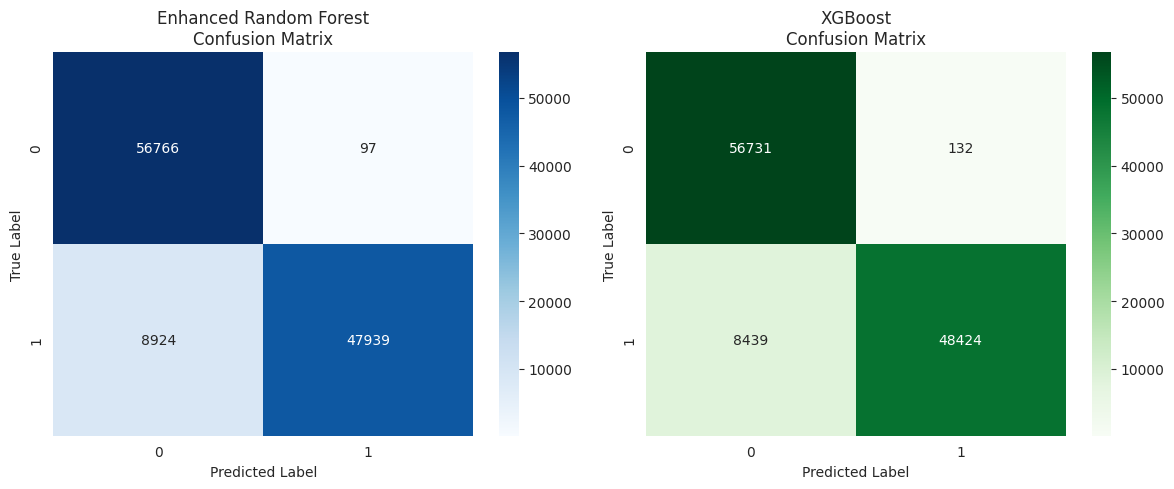

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# RF Confusion Matrix
sns.heatmap(confusion_matrix(y_val_balanced, y_val_pred),
            annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Enhanced Random Forest\nConfusion Matrix')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

# XGBoost Confusion Matrix
sns.heatmap(confusion_matrix(y_val_balanced, y_val_pred_xgb),
            annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('XGBoost\nConfusion Matrix')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')

plt.tight_layout()

## Dashboard Implementation Setup

In [25]:
!pip install streamlit
!pip install pyngrok
!pip install joblib xgboost scikit-learn pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.5 MB/s eta 0:00:00


In [26]:
import joblib
from sklearn.metrics import confusion_matrix


# Save models
models_to_save = {
    'rf_base': rf_base_model,
    'rf_model': rf_enhanced_model,
    'xgb_model': xgb_model,
}


for name, model in models_to_save.items():
    joblib.dump(model, f'/content/{name}.pkl')
    print(f"Saved {name}")


# Save preprocessed datasets
datasets_to_save = {
    'original': aml_df_scaled,  # Preprocessed original dataset
    # 'balanced_train': pd.DataFrame(X_train_balanced, columns=X_train.columns),
    # 'balanced_val': pd.DataFrame(X_val_balanced, columns=X_train.columns),
    # 'balanced_test': pd.DataFrame(X_test_balanced, columns=X_train.columns)
}

# Saving the datasets to CSV
for name, data in datasets_to_save.items():
    data.to_csv(f'/content/aml_df_{name}.csv', index=False)
    print(f"Saved {name} dataset to 'aml_df_{name}.csv'")



Saved rf_base
Saved rf_model
Saved xgb_model
Saved original dataset to 'aml_df_original.csv'


In [27]:
# After your clustering implementation
val_data = X_val_balanced.copy()
val_data['Cluster'] = cluster_labels_val
val_data['Class'] = y_val_balanced
val_data.to_csv('/content/aml_df_val_clustered.csv', index=False)

In [28]:
!ngrok authtoken 2qA677v0rAzEwjgvfPvUAZGUVZZ_2jdpGFmJpyCuJeHyFcgup

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [29]:
%%writefile app.py
# app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import joblib
import time
# Add to the imports section
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score  # Add this import
)
from sklearn.metrics import precision_recall_curve, average_precision_score

# Page Configuration
st.set_page_config(
    page_title="AML Detection System",
    page_icon="🔍",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Enhanced Styling
st.markdown("""
    <style>
    .main {padding: 0rem 1rem;}
    .stMetric {
        background-color: #f0f2f6;
        padding: 15px;
        border-radius: 10px;
        box-shadow: 2px 2px 10px rgba(0,0,0,0.1);
    }
    .stButton>button {
        background-color: #0066cc;
        color: white;
        padding: 10px 24px;
        border-radius: 5px;
        border: none;
    }
    </style>
""", unsafe_allow_html=True)

@st.cache_data
def load_data():
    try:
        # Load the clustered validation dataset
        df_val = pd.read_csv('/content/aml_df_val_clustered.csv')
        df_original = pd.read_csv('/content/aml_df_original.csv')

        # Verify required columns for validation data
        required_columns = ['Scaled_Amount', 'Scaled_Time', 'Class']
        missing_columns = [col for col in required_columns if col not in df_val.columns]

        if missing_columns:
            raise KeyError(f"Missing required columns: {missing_columns}")

        return df_val, df_original
    except Exception as e:
        st.error(f"Error loading validation data: {str(e)}")
        return None, None

@st.cache_resource
def load_models():
    try:
        # Load all models
        rf_base = joblib.load('/content/rf_base.pkl')
        rf_enhanced = joblib.load('/content/rf_model.pkl')
        xgb = joblib.load('/content/xgb_model.pkl')
        return rf_base, rf_enhanced, xgb
    except Exception as e:
        st.error(f"Error loading models: {str(e)}")
        return None, None, None

def get_predictions(model_name, X, y, rf_base, rf_enhanced, xgb):
    try:
        if model_name == "Base Random Forest":
            # For base model, remove Cluster if it exists
            X_pred = X.drop(['Cluster'], axis=1) if 'Cluster' in X.columns else X.copy()
            model = rf_base
        elif model_name == "Enhanced Random Forest":
            # For enhanced model, keep all features
            X_pred = X.copy()
            model = rf_enhanced
        else:  # XGBoost
            # For XGBoost, keep all features
            X_pred = X.copy()
            model = xgb

        y_pred = model.predict(X_pred)
        y_pred_proba = model.predict_proba(X_pred)[:, 1]

        return y_pred, y_pred_proba
    except Exception as e:
        st.error(f"Prediction error: {str(e)}")
        st.write("Features available:", X.columns.tolist())
        return None, None

# Login function
def login():
    st.markdown("<h1 style='text-align: center;'>🔒 AML Detection System</h1>",
                unsafe_allow_html=True)

    col1, col2, col3 = st.columns([1, 2, 1])
    with col2:
        username = st.text_input("Username")
        password = st.text_input("Password", type="password")

        if st.button("Login"):
            if username == "admin" and password == "admin":
                st.session_state['logged_in'] = True
                st.success("Login Successful!")
                time.sleep(1)
                st.rerun()
            else:
                st.error("Invalid credentials")

def main():
    # Load data and models
    df_val, df_original = load_data()
    rf_base, rf_enhanced, xgb = load_models()

    if df_val is None or df_original is None or rf_base is None:
        return

    # Header
    st.markdown("<h1 style='text-align: center;'>Anti-Money Laundering Detection System</h1>",
                unsafe_allow_html=True)

    # Sidebar
    with st.sidebar:
        st.markdown("### 📌 Dashboard Guide")
        with st.expander("How to Use"):
            st.markdown("""
            1. **Model Selection**: Choose between three models:
               - Base Random Forest (Original dataset)
               - Enhanced Random Forest (With clustering)
               - XGBoost (With clustering)

            2. **Filters**:
               - Adjust transaction amount range
               - Filter by time period
               - Select transaction type

            3. **Analysis Tabs**:
               - Model Performance: View ROC curves and metrics
               - Transaction Analysis: Explore patterns
               - Time Series: Analyze temporal trends
               - Real-time Detection: Test transactions
            """)

        st.markdown("### 🎛️ Control Panel")

        selected_model = st.selectbox(
            "Select Model",
            ["Base Random Forest", "Enhanced Random Forest", "XGBoost"],
            help="Choose the model for analysis"
        )

        # Model descriptions
        if selected_model == "Base Random Forest":
            st.info("Basic RF model without clustering")
            working_df = df_original.copy()
        elif selected_model == "Enhanced Random Forest":
            st.info("RF model with clustering enhancement")
            working_df = df_val.copy()
        else:
            st.info("XGBoost model with clustering")
            working_df = df_val.copy()

        # Transaction Type Filter
        transaction_type = st.selectbox(
            "Transaction Type",
            ["All", "Fraud", "Non-Fraud"]
        )

        # Time Range Filter
        time_range = st.slider(
            "Time Period",
            float(working_df['Scaled_Time'].min()),
            float(working_df['Scaled_Time'].max()),
            (float(working_df['Scaled_Time'].min()), float(working_df['Scaled_Time'].max()))
        )

        # Amount Range Filter
        amount_range = st.slider(
            "Transaction Amount",
            float(working_df['Scaled_Amount'].min()),
            float(working_df['Scaled_Amount'].max()),
            (float(working_df['Scaled_Amount'].min()), float(working_df['Scaled_Amount'].max()))
        )

        if st.button("Logout"):
            st.session_state['logged_in'] = False
            st.rerun()

    # Apply filters
    filtered_df = working_df[
        (working_df['Scaled_Amount'].between(amount_range[0], amount_range[1])) &
        (working_df['Scaled_Time'].between(time_range[0], time_range[1]))
    ]

    if transaction_type != "All":
        if transaction_type == "Fraud":
            filtered_df = filtered_df[filtered_df['Class'] == 1]
        else:
            filtered_df = filtered_df[filtered_df['Class'] == 0]

    # Key Metrics Display
    st.markdown("### 📊 Key Metrics")
    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(
            "Total Transactions",
            f"{len(filtered_df):,}",
            delta=f"{len(filtered_df)/len(working_df)*100:.1f}% of total"
        )

    with col2:
        fraud_count = len(filtered_df[filtered_df['Class'] == 1])
        st.metric(
            "Fraud Transactions",
            f"{fraud_count:,}",
            delta=f"{fraud_count/len(filtered_df)*100:.2f}% of filtered"
        )

    with col3:
        avg_amount = filtered_df['Scaled_Amount'].mean()
        st.metric(
            "Average Transaction Amount",
            f"{avg_amount:.2f}",
            delta=f"{avg_amount - working_df['Scaled_Amount'].mean():.2f} vs overall"
        )

    # Updated tabs
    tab1, tab2, tab3, tab4 = st.tabs([
        "🎯 Model Performance",
        "🔍 Transaction Analysis",
        "📈 Time Series",
        "⚡ Real-time Detection"
    ])

    with tab1:
        col1, col2 = st.columns(2)
        with col1:
            try:
                # ROC Curve (existing code)
                features_for_prediction = filtered_df.drop(['Class'], axis=1)
                y = filtered_df['Class']

                y_pred, y_pred_proba = get_predictions(
                    selected_model,
                    features_for_prediction,
                    y,
                    rf_base,
                    rf_enhanced,
                    xgb
                )

                # ROC Curve
                fpr, tpr, _ = roc_curve(y, y_pred_proba)
                auc_score = roc_auc_score(y, y_pred_proba)

                fig = go.Figure()
                fig.add_trace(go.Scatter(
                    x=fpr, y=tpr,
                    name=f'ROC (AUC = {auc_score:.3f})'
                ))
                fig.add_trace(go.Scatter(
                    x=[0, 1], y=[0, 1],
                    line=dict(dash='dash', color='gray'),
                    name='Random'
                ))
                fig.update_layout(
                    title=f'{selected_model} ROC Curve',
                    xaxis_title='False Positive Rate',
                    yaxis_title='True Positive Rate'
                )
                st.plotly_chart(fig)

                # Precision-Recall Curve
                precision, recall, _ = precision_recall_curve(y, y_pred_proba)
                avg_precision = average_precision_score(y, y_pred_proba)

                fig = go.Figure()
                fig.add_trace(go.Scatter(
                    x=recall, y=precision,
                    name=f'PR (AP = {avg_precision:.3f})'
                ))
                fig.update_layout(
                    title='Precision-Recall Curve',
                    xaxis_title='Recall',
                    yaxis_title='Precision'
                )
                st.plotly_chart(fig)

            except Exception as e:
                st.error(f"Error in curve generation: {str(e)}")

        with col2:
            try:
                # Confusion Matrix
                cm = confusion_matrix(y, y_pred)
                fig = go.Figure(data=go.Heatmap(
                    z=cm,
                    x=['Non-Fraud', 'Fraud'],
                    y=['Non-Fraud', 'Fraud'],
                    text=cm,
                    texttemplate="%{text}",
                    textfont={"size": 16},
                    colorscale='Blues'
                ))
                fig.update_layout(title='Confusion Matrix')
                st.plotly_chart(fig)

                # Classification Report
                report = classification_report(y, y_pred, output_dict=True)
                df_report = pd.DataFrame(report).transpose()
                st.markdown("### Classification Report")
                st.dataframe(df_report.style.format("{:.3f}"))

                # Additional Metrics
                st.markdown("### Performance Metrics")
                metrics_df = pd.DataFrame({
                    'Metric': ['Accuracy', 'AUC-ROC', 'Avg Precision'],
                    'Value': [
                        accuracy_score(y, y_pred),
                        auc_score,
                        avg_precision
                    ]
                })
                st.table(metrics_df.style.format({'Value': '{:.3f}'}))

            except Exception as e:
                st.error(f"Error in metrics generation: {str(e)}")

    # Feature Importance (if available)
    # Get the correct model based on selection
    if selected_model == "Base Random Forest":
        current_model = rf_base
    elif selected_model == "Enhanced Random Forest":
        current_model = rf_enhanced
    else:
        current_model = xgb

    if hasattr(current_model, 'feature_importances_'):
        st.markdown("### Feature Importance")
        importance = pd.DataFrame({
            'Feature': features_for_prediction.columns,
            'Importance': current_model.feature_importances_
        }).sort_values('Importance', ascending=False)

        fig = px.bar(
            importance.head(10),
            x='Importance',
            y='Feature',
            title=f'Top 10 Important Features - {selected_model}',
            orientation='h'
        )
        st.plotly_chart(fig)

    # Model Comparison (if selected)
    if st.checkbox("Show Model Comparison"):
        st.markdown("### Model Comparison")
        models = {
            "Base Random Forest": rf_base,
            "Enhanced Random Forest": rf_enhanced,
            "XGBoost": xgb
        }

        comparison_metrics = []
        for model_name, model in models.items():
            y_pred, y_pred_proba = get_predictions(
                model_name,
                features_for_prediction,
                y,
                rf_base,
                rf_enhanced,
                xgb
            )
            comparison_metrics.append({
                'Model': model_name,
                'Accuracy': accuracy_score(y, y_pred),
                'AUC-ROC': roc_auc_score(y, y_pred_proba),
                'Avg Precision': average_precision_score(y, y_pred_proba)
            })

        comparison_df = pd.DataFrame(comparison_metrics)
        st.dataframe(comparison_df.style.format({
            'Accuracy': '{:.3f}',
            'AUC-ROC': '{:.3f}',
            'Avg Precision': '{:.3f}'
        }))

    # Transaction Analysis Tab
    with tab2:
        col1, col2 = st.columns(2)
        with col1:
            fig = px.histogram(
                filtered_df,
                x='Scaled_Amount',
                color='Class',
                nbins=50,
                title='Transaction Amount Distribution'
            )
            st.plotly_chart(fig)

        with col2:
            fig = px.scatter(
                filtered_df,
                x='Scaled_Amount',
                y='Scaled_Time',
                color='Class',
                title='Transaction Patterns'
            )
            st.plotly_chart(fig)

    # Time Series Analysis Tab
    with tab3:
        time_series = filtered_df.groupby('Scaled_Time')['Class'].mean().rolling(window=50).mean()
        fig = px.line(
            x=time_series.index,
            y=time_series.values,
            title='Fraud Rate Over Time (Moving Average)',
            labels={'x': 'Time', 'y': 'Fraud Rate'}
        )
        st.plotly_chart(fig)

    # Real-time Detection Tab (Placeholder)
    with tab4:
        st.markdown("### ⚡ Real-time Transaction Detection")
        st.info("This feature is currently under development.")
        st.markdown("""
        Future capabilities will include:
        - Real-time transaction analysis
        - Risk scoring
        - Instant fraud detection
        - Alert generation
        """)

# Initialize session state and run application
if 'logged_in' not in st.session_state:
    st.session_state['logged_in'] = False

if not st.session_state['logged_in']:
    login()
else:
    main()


Writing app.py


In [30]:
!streamlit run app.py &>/dev/null&
from pyngrok import ngrok
public_url = ngrok.connect(8501, "http")
print(public_url)

NgrokTunnel: "https://dabd-34-16-50-117.ngrok-free.app" -> "http://localhost:8501"


In [31]:
# # Import necessary libraries
# from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
# from sklearn.metrics import make_scorer, roc_auc_score, precision_score, recall_score, f1_score

# # Define custom scoring metrics
# scoring = {
#     'auc_roc': make_scorer(roc_auc_score),
#     'precision': make_scorer(precision_score),
#     'recall': make_scorer(recall_score),
#     'f1': make_scorer(f1_score)
# }

# # Initialize StratifiedKFold for balanced class distribution
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Cross-validation for Random Forest
# print("Enhanced Random Forest Cross-Validation:")
# print("="*50)

# cv_scores_rf = {
#     'auc_roc': cross_val_score(rf_enhanced_model, X_train_balanced, y_train_balanced,
#                               scoring='roc_auc', cv=skf),
#     'precision': cross_val_score(rf_enhanced_model, X_train_balanced, y_train_balanced,
#                                 scoring='precision', cv=skf),
#     'recall': cross_val_score(rf_enhanced_model, X_train_balanced, y_train_balanced,
#                              scoring='recall', cv=skf),
#     'f1': cross_val_score(rf_enhanced_model, X_train_balanced, y_train_balanced,
#                          scoring='f1', cv=skf)
# }

# for metric, scores in cv_scores_rf.items():
#     print(f"{metric.upper()}:")
#     print(f"Mean: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})")

# # Cross-validation for XGBoost
# print("\nXGBoost Cross-Validation:")
# print("="*50)

# cv_scores_xgb = {
#     'auc_roc': cross_val_score(xgb_model, X_train_balanced, y_train_balanced,
#                               scoring='roc_auc', cv=skf),
#     'precision': cross_val_score(xgb_model, X_train_balanced, y_train_balanced,
#                                 scoring='precision', cv=skf),
#     'recall': cross_val_score(xgb_model, X_train_balanced, y_train_balanced,
#                              scoring='recall', cv=skf),
#     'f1': cross_val_score(xgb_model, X_train_balanced, y_train_balanced,
#                          scoring='f1', cv=skf)
# }

# for metric, scores in cv_scores_xgb.items():
#     print(f"{metric.upper()}:")
#     print(f"Mean: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})")

# # Visualize cross-validation results
# plt.figure(figsize=(12, 6))

# # Plot RF scores
# plt.subplot(1, 2, 1)
# box_data_rf = [cv_scores_rf[metric] for metric in ['auc_roc', 'precision', 'recall', 'f1']]
# plt.boxplot(box_data_rf, labels=['AUC-ROC', 'Precision', 'Recall', 'F1'])
# plt.title('Random Forest Cross-Validation Scores')
# plt.grid(True, alpha=0.3)

# # Plot XGBoost scores
# plt.subplot(1, 2, 2)
# box_data_xgb = [cv_scores_xgb[metric] for metric in ['auc_roc', 'precision', 'recall', 'f1']]
# plt.boxplot(box_data_xgb, labels=['AUC-ROC', 'Precision', 'Recall', 'F1'])
# plt.title('XGBoost Cross-Validation Scores')
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Save cross-validation results
# cv_results = {
#     'Random Forest': {metric: {'mean': scores.mean(), 'std': scores.std()}
#                      for metric, scores in cv_scores_rf.items()},
#     'XGBoost': {metric: {'mean': scores.mean(), 'std': scores.std()}
#                 for metric, scores in cv_scores_xgb.items()}
# }

# # Convert to DataFrame for easier viewing
# cv_results_df = pd.DataFrame({
#     ('Random Forest', 'Mean'): [cv_results['Random Forest'][m]['mean'] for m in ['auc_roc', 'precision', 'recall', 'f1']],
#     ('Random Forest', 'Std'): [cv_results['Random Forest'][m]['std'] for m in ['auc_roc', 'precision', 'recall', 'f1']],
#     ('XGBoost', 'Mean'): [cv_results['XGBoost'][m]['mean'] for m in ['auc_roc', 'precision', 'recall', 'f1']],
#     ('XGBoost', 'Std'): [cv_results['XGBoost'][m]['std'] for m in ['auc_roc', 'precision', 'recall', 'f1']]
# }, index=['AUC-ROC', 'Precision', 'Recall', 'F1'])

# print("\nCross-Validation Results Summary:")
# print("="*50)
# print(cv_results_df.round(3))